# **Polars: Conhecendo a ferramenta**

Uma equipe de empreendedores deseja abrir uma nova franquia de restaurantes e precisa tomar decisões estratégicas baseadas em dados. Para isso, é essencial entender o mercado, identificar padrões de consumo, avaliar pontos fortes e fracos dos restaurantes e reconhecer as preferências dos clientes.

No entanto, os dados disponíveis sobre restaurantes estão dispersos em grandes bases de dados, e interpretar essas informações de forma eficiente exige um processo robusto de exploração e análise. Além disso, a tomada de decisão precisa ser baseada em métricas concretas, evitando depender apenas de intuição ou suposições.

Nosso papel neste projeto é realizar uma análise aprofundada dos dados de restaurantes, utilizando a biblioteca **Polars** para manipulação eficiente dos dados e técnicas de visualização para extrair insights relevantes. O objetivo é fornecer recomendações baseadas em evidências que auxiliem na escolha do **tipo de restaurante, preço competitivo e cardápio ideal** para garantir o sucesso da nova franquia.

## 📖 **Conhecendo os dados**

### Realizando a leitura dos dados

Antes de abrir uma nova franquia de restaurantes, é fundamental entender o cenário atual do mercado. Para isso, começamos explorando uma base de dados contendo informações sobre diversos restaurantes, suas avaliações, tipos de culinária, faixa de preço e a experiência dos clientes.

Nosso primeiro passo é carregar e visualizar a **estrutura dos dados**, garantindo que as informações estejam organizadas e prontas para uma análise detalhada. A partir dessa visão inicial, poderemos identificar padrões, tendências e oportunidades que irão guiar a tomada de decisão estratégica para a nova franquia.

In [1]:
import polars as pl

In [2]:
restaurantes = pl.read_csv('/content/drive/MyDrive/dados/restaurantes.csv', encoding = 'utf-8')

In [3]:
restaurantes

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,str,i64,str,str,str,str,str,str,str,str
"""Jalsa""","""Yes""","""Yes""","""4.1/5""",775,"""Casual Dining""","""Pasta, Lunch Buffet, Masala Pa…","""North Indian, Mughlai, Chinese""","""800""","""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""","""4.1/5""",787,"""Casual Dining""","""Momos, Lunch Buffet, Chocolate…","""Chinese, North Indian, Thai""","""800""","""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""","""3.8/5""",918,"""Cafe, Casual Dining""","""Churros, Cannelloni, Minestron…","""Cafe, Mexican, Italian""","""800""","""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""","""3.7/5""",88,"""Quick Bites""","""Masala Dosa""","""South Indian, North Indian""","""300""","""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""","""3.8/5""",166,"""Casual Dining""","""Panipuri, Gol Gappe""","""North Indian, Rajasthani""","""600""","""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""","""3.6 /5""",27,"""Bar""",null,"""Continental""","""1,500""","""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""","""600""","""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""","""2,000""","""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [4]:
restaurantes.glimpse()

Rows: 51717
Columns: 13
$ name                        <str> 'Jalsa', 'Spice Elephant', 'San Churro Cafe', 'Addhuri Udupi Bhojana', 'Grand Village', 'Timepass Dinner', 'Rosewood International Hotel - Bar & Restaurant', 'Onesta', 'Penthouse Cafe', 'Smacznego'
$ online_order                <str> 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes'
$ book_table                  <str> 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No'
$ rate                        <str> '4.1/5', '4.1/5', '3.8/5', '3.7/5', '3.8/5', '3.8/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5'
$ votes                       <i64> 775, 787, 918, 88, 166, 286, 8, 2556, 324, 504
$ rest_type                   <str> 'Casual Dining', 'Casual Dining', 'Cafe, Casual Dining', 'Quick Bites', 'Casual Dining', 'Casual Dining', 'Casual Dining', 'Casual Dining, Cafe', 'Cafe', 'Cafe'
$ dish_liked                  <str> 'Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup', 'Mom

### Convertendo valores numéricos

Para definir o posicionamento estratégico da nova franquia, é essencial compreender a distribuição de preços no mercado. Um restaurante pode se destacar tanto pela acessibilidade quanto pela exclusividade, e entender essa dinâmica nos ajudará a escolher a melhor abordagem.

O primeiro passo é tratar a coluna de custo aproximado para duas pessoas, garantindo que os valores estejam num formato adequado para análise. Em seguida, calculamos os valores mínimo, máximo e médio para termos uma visão geral dos preços praticados.

In [5]:
restaurantes.with_columns(
    pl.col('approx_cost(for two people)')
    .str.replace(',', '')
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,str,i64,str,str,str,str,str,str,str,str
"""Jalsa""","""Yes""","""Yes""","""4.1/5""",775,"""Casual Dining""","""Pasta, Lunch Buffet, Masala Pa…","""North Indian, Mughlai, Chinese""","""800""","""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""","""4.1/5""",787,"""Casual Dining""","""Momos, Lunch Buffet, Chocolate…","""Chinese, North Indian, Thai""","""800""","""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""","""3.8/5""",918,"""Cafe, Casual Dining""","""Churros, Cannelloni, Minestron…","""Cafe, Mexican, Italian""","""800""","""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""","""3.7/5""",88,"""Quick Bites""","""Masala Dosa""","""South Indian, North Indian""","""300""","""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""","""3.8/5""",166,"""Casual Dining""","""Panipuri, Gol Gappe""","""North Indian, Rajasthani""","""600""","""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""","""3.6 /5""",27,"""Bar""",null,"""Continental""","""1500""","""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""","""600""","""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""","""2000""","""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [6]:
restaurantes.with_columns(
    pl.col('approx_cost(for two people)')
    .str.replace(',', '')
    .cast(pl.Float64)
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,str,i64,str,str,str,f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""","""4.1/5""",775,"""Casual Dining""","""Pasta, Lunch Buffet, Masala Pa…","""North Indian, Mughlai, Chinese""",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""","""4.1/5""",787,"""Casual Dining""","""Momos, Lunch Buffet, Chocolate…","""Chinese, North Indian, Thai""",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""","""3.8/5""",918,"""Cafe, Casual Dining""","""Churros, Cannelloni, Minestron…","""Cafe, Mexican, Italian""",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""","""3.7/5""",88,"""Quick Bites""","""Masala Dosa""","""South Indian, North Indian""",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""","""3.8/5""",166,"""Casual Dining""","""Panipuri, Gol Gappe""","""North Indian, Rajasthani""",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""","""3.6 /5""",27,"""Bar""",null,"""Continental""",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [7]:
restaurantes = restaurantes.with_columns(
    pl.col('approx_cost(for two people)')
    .str.replace(',', '')
    .cast(pl.Float64)
)

In [8]:
restaurantes.select(
    pl.col('approx_cost(for two people)').max().alias('max'),
    pl.col('approx_cost(for two people)').min().alias('min'),
    pl.col('approx_cost(for two people)').mean().round(2).alias('média')
)

max,min,média
f64,f64,f64
6000.0,40.0,555.43


Os resultados obtidos nos fornecem um panorama inicial sobre os preços no mercado. O valor mínimo indica as opções mais acessíveis, enquanto o máximo aponta o teto de consumo para um jantar para duas pessoas. Já a média nos ajuda a entender o que os clientes geralmente estão dispostos a pagar.

Com essa base, podemos aprofundar a análise explorando a relação entre preço e avaliação, segmentando restaurantes por faixas de preço e comparando variações entre diferentes tipos de estabelecimentos e regiões. Essas informações serão fundamentais para definir a estratégia de precificação da nova franquia.

## 🔧 **Realizando transformações nos dados**

### Usando o Regex

A reputação de um restaurante é um fator decisivo para atrair clientes. Avaliações refletem a experiência dos consumidores e ajudam a identificar padrões de qualidade e preferência no mercado.

Para garantir que essa análise seja precisa, primeiro extraímos e transformamos a coluna de avaliação (rate), convertendo-a para um formato numérico adequado. Em seguida, identificamos a avaliação máxima e mínima dos restaurantes, o que nos dará uma noção da variação na qualidade percebida pelos clientes.

In [9]:
restaurantes.with_columns(
    pl.col('rate')
    .str.extract(r'^([\d\.]+)')
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,str,i64,str,str,str,f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""","""4.1""",775,"""Casual Dining""","""Pasta, Lunch Buffet, Masala Pa…","""North Indian, Mughlai, Chinese""",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""","""4.1""",787,"""Casual Dining""","""Momos, Lunch Buffet, Chocolate…","""Chinese, North Indian, Thai""",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""","""3.8""",918,"""Cafe, Casual Dining""","""Churros, Cannelloni, Minestron…","""Cafe, Mexican, Italian""",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""","""3.7""",88,"""Quick Bites""","""Masala Dosa""","""South Indian, North Indian""",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""","""3.8""",166,"""Casual Dining""","""Panipuri, Gol Gappe""","""North Indian, Rajasthani""",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""","""3.6""",27,"""Bar""",null,"""Continental""",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [10]:
restaurantes.with_columns(
    pl.col('rate')
    .str.extract(r'^([\d\.]+)')
    .cast(pl.Float64)
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,str,str,f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","""Pasta, Lunch Buffet, Masala Pa…","""North Indian, Mughlai, Chinese""",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","""Momos, Lunch Buffet, Chocolate…","""Chinese, North Indian, Thai""",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","""Churros, Cannelloni, Minestron…","""Cafe, Mexican, Italian""",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","""Masala Dosa""","""South Indian, North Indian""",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","""Panipuri, Gol Gappe""","""North Indian, Rajasthani""",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"""Continental""",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"""Finger Food""",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [11]:
restaurantes = restaurantes.with_columns(
    pl.col('rate')
    .str.extract(r'^([\d\.]+)')
    .cast(pl.Float64)
)

In [12]:
restaurantes.select(
    pl.col('rate').max().alias('max'),
    pl.col('rate').min().alias('min')
)

max,min
f64,f64
4.9,1.8


Os valores obtidos revelam a amplitude das avaliações no mercado, desde os restaurantes mais bem avaliados até aqueles com pior reputação. Essa informação é crucial para entendermos o nível de exigência dos clientes e identificarmos benchmarks de qualidade.

Com essa base, podemos aprofundar a análise investigando a relação entre avaliações e outros fatores, como faixa de preço, tipo de restaurante e pratos mais populares, garantindo insights valiosos para o posicionamento da nova franquia.

### Convertendo textos para listas

Compreender as preferências gastronômicas dos clientes é essencial para definir o cardápio da nova franquia. Restaurantes bem-sucedidos geralmente possuem pratos que se destacam e atraem clientes recorrentes.

Para garantir uma análise precisa, precisamos limpar e estruturar os dados das colunas "dish_liked" (pratos favoritos) e "cuisines" (tipos de culinária). Isso envolve dividir as listas de itens e remover espaços desnecessários, tornando os dados mais organizados para futuras análises.

In [13]:
restaurantes.with_columns(
    pl.col('dish_liked')
    .cast(pl.List(pl.String)),
    pl.col('cuisines')
    .cast(pl.List(pl.String))
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup""]","[""North Indian, Mughlai, Chinese""]",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani""]","[""Chinese, North Indian, Thai""]",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza""]","[""Cafe, Mexican, Italian""]",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","[""Masala Dosa""]","[""South Indian, North Indian""]",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","[""Panipuri, Gol Gappe""]","[""North Indian, Rajasthani""]",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"[""Continental""]",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [14]:
restaurantes.with_columns(
    pl.col('dish_liked')
    .str.split(','),
    pl.col('cuisines')
    .str.split(',')
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta"", "" Lunch Buffet"", … "" Sweet Corn Soup""]","[""North Indian"", "" Mughlai"", "" Chinese""]",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos"", "" Lunch Buffet"", … "" Chicken Biryani""]","[""Chinese"", "" North Indian"", "" Thai""]",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros"", "" Cannelloni"", … "" Veg Supreme Pizza""]","[""Cafe"", "" Mexican"", "" Italian""]",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","[""Masala Dosa""]","[""South Indian"", "" North Indian""]",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","[""Panipuri"", "" Gol Gappe""]","[""North Indian"", "" Rajasthani""]",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"[""Continental""]",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [15]:
restaurantes.with_columns(
    pl.col('dish_liked')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars()),
    pl.col('cuisines')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars())
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta"", ""Lunch Buffet"", … ""Sweet Corn Soup""]","[""North Indian"", ""Mughlai"", ""Chinese""]",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""[]""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos"", ""Lunch Buffet"", … ""Chicken Biryani""]","[""Chinese"", ""North Indian"", ""Thai""]",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""[]""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros"", ""Cannelloni"", … ""Veg Supreme Pizza""]","[""Cafe"", ""Mexican"", ""Italian""]",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""[]""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","[""Masala Dosa""]","[""South Indian"", ""North Indian""]",300.0,"""[('Rated 4.0', ""RATED\n Great…","""[]""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","[""Panipuri"", ""Gol Gappe""]","[""North Indian"", ""Rajasthani""]",600.0,"""[('Rated 4.0', 'RATED\n Very …","""[]""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"[""Continental""]",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""[]""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",600.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",2000.0,"""[]""","""[]""","""Pubs and bars""","""Whitefield"""


In [16]:
restaurantes = restaurantes.with_columns(
    pl.col('dish_liked')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars()),
    pl.col('cuisines')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars())
)

### Identificando dados únicos

O cardápio de um restaurante é um dos principais fatores que influenciam a experiência do cliente e a decisão de consumo. Analisar os itens disponíveis pode revelar padrões e tendências gastronômicas que ajudam a definir o melhor mix de produtos para a nova franquia.

No entanto, os dados brutos podem conter formatações indesejadas, como colchetes e espaços extras. Para garantir uma análise precisa, primeiro limpamos e estruturamos a coluna "menu_item", transformando os itens do cardápio em listas organizadas.

In [17]:
restaurantes.select(
    pl.col('menu_item').unique()
)

menu_item
str
"""['Paper Dosa', 'Benne Kali Min…"
"""['Hot and Crispy Chicken', 'Sn…"
"""['Dark Chocolate and Crushed O…"
"""['Ghee Rice', 'Chicken Biryani…"
"""['Bhel Puri', 'Sev Puri', 'Mas…"
…
"""['Beef Roast', 'Pork Vindhalo'…"
"""['Anjur Rasmalai Box [20 Piece…"
"""['South Meal', 'Mini Meal', '2…"


In [18]:
restaurantes.select(
    pl.col('menu_item').unique()
).item(0, 0)

"['Sangri ki Sabzi', 'Besan Bhindi', 'Kadai Paneer', 'Aloo Kulcha', 'Normal Veg Thali', 'Premium Veg Thali', 'Sangri ki Sabzi', 'Gatte ki Sabzi', 'Papad ki Sabzi', 'Mangodi ki Sabzi', 'Marwadi Kadhi', 'Kadhi Masala', 'Plain Khichdi', 'Veg Khichdi', 'Besan Bhindi', 'Besan Shimla Mirch', 'Normal Veg Thali', 'Premium Veg Thali', 'Chole Bhature', 'Pav Bhaji', 'Cheese Paw Bhaji', 'Matar Paneer', 'Kadai Paneer', 'Paneer Butter Masala', 'Paneer Do Pyaza', 'Paneer Jhaal Farezi', 'Mixed Vegetable', 'Veg Kohlapuri', 'Aloo Jeera', 'Aloo Methi', 'Aloo Do Pyaza', 'Aloo Dahi', 'Plain Bhindi', 'Daal Fry', 'Daal Makhani', 'Rajma Masala', 'Chola Masala', 'Chana Masala', 'Chana Daal', 'Plain Roti', 'Ghee Roti', 'Missi Roti', 'Onion Missi Roti', 'Plain Naan', 'Butter Naan', 'Aloo Kulcha', 'Paneer Kulcha', 'Aloo Paratha', 'Onion Paratha', 'Methi Paratha', 'Lachha Paratha', 'Paneer Paratha', 'Cheese Paratha', 'Plain Rice', 'Jeera Rice', 'Fried Rice', 'Veg Biryani', 'Idli', 'Plain Dosa', 'Masala Dosa', 'Che

In [19]:
restaurantes.with_columns(
    pl.col('menu_item')
    .str.replace('\[', '')
    .str.replace('\]', '')
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,str,str,str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta"", ""Lunch Buffet"", … ""Sweet Corn Soup""]","[""North Indian"", ""Mughlai"", ""Chinese""]",800.0,"""[('Rated 4.0', 'RATED\n A bea…","""""","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos"", ""Lunch Buffet"", … ""Chicken Biryani""]","[""Chinese"", ""North Indian"", ""Thai""]",800.0,"""[('Rated 4.0', 'RATED\n Had b…","""""","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros"", ""Cannelloni"", … ""Veg Supreme Pizza""]","[""Cafe"", ""Mexican"", ""Italian""]",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","""""","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","[""Masala Dosa""]","[""South Indian"", ""North Indian""]",300.0,"""[('Rated 4.0', ""RATED\n Great…","""""","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","[""Panipuri"", ""Gol Gappe""]","[""North Indian"", ""Rajasthani""]",600.0,"""[('Rated 4.0', 'RATED\n Very …","""""","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"[""Continental""]",1500.0,"""[('Rated 5.0', ""RATED\n Food …","""""","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",600.0,"""[]""","""""","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",2000.0,"""[]""","""""","""Pubs and bars""","""Whitefield"""


In [20]:
restaurantes.with_columns(
    pl.col('menu_item')
    .str.replace('\[', '')
    .str.replace('\]', '')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars())
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,str,list[str],str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta"", ""Lunch Buffet"", … ""Sweet Corn Soup""]","[""North Indian"", ""Mughlai"", ""Chinese""]",800.0,"""[('Rated 4.0', 'RATED\n A bea…","[""""]","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos"", ""Lunch Buffet"", … ""Chicken Biryani""]","[""Chinese"", ""North Indian"", ""Thai""]",800.0,"""[('Rated 4.0', 'RATED\n Had b…","[""""]","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros"", ""Cannelloni"", … ""Veg Supreme Pizza""]","[""Cafe"", ""Mexican"", ""Italian""]",800.0,"""[('Rated 3.0', ""RATED\n Ambie…","[""""]","""Buffet""","""Banashankari"""
"""Addhuri Udupi Bhojana""","""No""","""No""",3.7,88,"""Quick Bites""","[""Masala Dosa""]","[""South Indian"", ""North Indian""]",300.0,"""[('Rated 4.0', ""RATED\n Great…","[""""]","""Buffet""","""Banashankari"""
"""Grand Village""","""No""","""No""",3.8,166,"""Casual Dining""","[""Panipuri"", ""Gol Gappe""]","[""North Indian"", ""Rajasthani""]",600.0,"""[('Rated 4.0', 'RATED\n Very …","[""""]","""Buffet""","""Banashankari"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Best Brews - Four Points by Sh…","""No""","""No""",3.6,27,"""Bar""",null,"[""Continental""]",1500.0,"""[('Rated 5.0', ""RATED\n Food …","[""""]","""Pubs and bars""","""Whitefield"""
"""Vinod Bar And Restaurant""","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",600.0,"""[]""","[""""]","""Pubs and bars""","""Whitefield"""
"""Plunge - Sheraton Grand Bengal…","""No""","""No""",null,0,"""Bar""",null,"[""Finger Food""]",2000.0,"""[]""","[""""]","""Pubs and bars""","""Whitefield"""


In [21]:
restaurantes = restaurantes.with_columns(
    pl.col('menu_item')
    .str.replace('\[', '')
    .str.replace('\]', '')
    .str.split(',')
    .list.eval(pl.element().str.strip_chars())
)

In [22]:
restaurantes.filter(
    pl.col('menu_item').list.len() > 1
).select(
    pl.col('menu_item')
).item(0,0).to_list()

["'Chocolate Fantasy (Pack Of 5)'",
 "'Pan Cake (Pack Of 6)'",
 "'Gulab Jamun (Pack Of 10)'",
 "'Gulkand Shot (Pack Of 5)'",
 "'Chocolate Decadence (Pack of 2)'",
 "'CheeseCake (Pack Of 2)'",
 "'Red Velvet Slice Cake (Pack of 2)'",
 "'Red Velvet Slice Cake & Cheese Cake (Pack of 2)'",
 "'Red Velvet Slice Cake & Chocolate Decadence Cake (Pack of 2)'",
 "'Hazelnut Brownie (Pack of 2)'",
 "'Moments'",
 "'Red Velvet Cake With Butter Cream Frosting (750 Gm)'",
 "'Red Velvet Slice Cake (Pack of 2)'",
 "'Red Velvet Slice Cake & Cheese Cake (Pack of 2)'",
 "'Red Velvet Slice Cake & Chocolate Decadence Cake (Pack of 2)'",
 "'Red Velvet Slice Cake (Pack of 1)'",
 "'Valentine Red Velvet Jar'",
 "'Valentine Chocolate Jar'",
 "'Valentines Jar Combo'",
 "'Pink Guava 500 ML'",
 "'Oreo Vanilla 500 ML'",
 "'Cookie Crumble 500 ML'",
 "'Chocolate Fantasy'",
 "'Gulkand-E-Bahar'",
 "'Pan Cake'",
 "'Hazelnut Brownie (Pack Of 1)'",
 "'Gulab Jamun (Pack Of 2)'",
 "'Plum Cake'",
 "'Red Velvet Cake With Butter 

Agora, os dados do cardápio estão devidamente formatados e prontos para análises mais aprofundadas.

### Trabalhando com tipos de dados aninhados

A experiência do cliente é um dos fatores mais importantes para o sucesso de um restaurante. As avaliações e comentários fornecem insights valiosos sobre a percepção do público, ajudando a identificar pontos fortes e áreas de melhoria.

Para garantir que os dados sejam analisados corretamente, primeiro precisamos limpar e estruturar a coluna "reviews_list", removendo caracteres indesejados e separando os comentários individuais. Isso tornará a análise mais eficiente e permitirá extrair insights relevantes.

In [23]:
restaurantes.select(
    pl.col('reviews_list')
).item(0, 0)

'[(\'Rated 4.0\', \'RATED\\n  A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items available. But the taste and service was not compromised at all.The only complaint is that the breads could have been better.Would surely like to come here again.\'), (\'Rated 4.0\', \'RATED\\n  I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\\nCheers\'), (\'Rated 2.0\', \'RATED\\n  Its a restaurant near to Banashankari BDA. Me along with few of my office friends visited to have buffet but unfortunately they only provide veg buffet. On inquiring they said this plac

In [24]:
restaurantes.with_columns(
    pl.col('reviews_list')
    .str.replace('\[', '')
    .str.replace('\]', '')
    .str.replace('\(', '')
).select(
    pl.col('reviews_list')
).item(0, 0)


'\'Rated 4.0\', \'RATED\\n  A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items available. But the taste and service was not compromised at all.The only complaint is that the breads could have been better.Would surely like to come here again.\'), (\'Rated 4.0\', \'RATED\\n  I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\\nCheers\'), (\'Rated 2.0\', \'RATED\\n  Its a restaurant near to Banashankari BDA. Me along with few of my office friends visited to have buffet but unfortunately they only provide veg buffet. On inquiring they said this place 

In [25]:
restaurantes.with_columns(
    pl.col('reviews_list')
    .str.replace('\[', '')
    .str.replace('\]', '')
    .str.replace('\(', '')
    .str.split('), (')
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,list[str],list[str],str,str
"""Jalsa""","""Yes""","""Yes""",4.1,775,"""Casual Dining""","[""Pasta"", ""Lunch Buffet"", … ""Sweet Corn Soup""]","[""North Indian"", ""Mughlai"", ""Chinese""]",800.0,"[""'Rated 4.0', 'RATED\n A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items available. But the taste and service was not compromised at all.The only complaint is that the breads could have been better.Would surely like to come here again.'"", ""'Rated 4.0', 'RATED\n I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\nCheers'"", … ""'Rated 4.0', 'RATED\n The place is nice and comfortable. Food wise all jalea outlets maintain a good standard. The soya chaap was a standout dish. Clearly one of trademark dish as per me and a must try.\n\nThe only concern is the parking. It very congested and limited to just 5cars. The basement parking is very steep and makes it cumbersome')""]","[""""]","""Buffet""","""Banashankari"""
"""Spice Elephant""","""Yes""","""No""",4.1,787,"""Casual Dining""","[""Momos"", ""Lunch Buffet"", … ""Chicken Biryani""]","[""Chinese"", ""North Indian"", ""Thai""]",800.0,"[""'Rated 4.0', 'RATED\n Had been here for dinner with family. Turned out to be a good choose suitable for all ages of people. Can try this place. We liked the most was their starters. Service is good. Prices are affordable. Will recommend this restaurant for early dinner. The place is little noisy.'"", ""'Rated 3.0', 'RATED\n The ambience is really nice, staff is courteous. The price is pretty high for the quantity, but overall the experience was fine. The quality of food is nice but nothing extraordinary. They also have buffet(only veg)'"", … ""'Rated 4.0', 'RATED\n Zomato gold partner at this price. It was insane. They have really nice food. small place with very courteous staff and very cheap food for this ambience. Cost of soups is 80-100. Starters from 150-250. Main course 200-300. Cost for two was 800 for us.')""]","[""""]","""Buffet""","""Banashankari"""
"""San Churro Cafe""","""Yes""","""No""",3.8,918,"""Cafe, Casual Dining""","[""Churros"", ""Cannelloni"", … ""Veg Supreme Pizza""]","[""Cafe"", ""Mexican"", ""Italian""]",800.0,"[""'Rated 3.0', ""RATED\n Ambience is not that good enough and it's not a pocket friendly cafe and the quantity is not that good and desserts are too good enough ??.."""", ""'Rated 3.0', ""RATED\n \nWent there for a quick bite with friends.\nThe ambience had more of corporate feel. I would say it was unique.\nTried nachos, pasta churros and lasagne.\n\nNachos were pathetic.( Seriously don't order)\nPasta was okayish.\nLasagne was good.\nNutella churros were the best.\nOverall an okayish experience!\nPeace ??"""", … ""'Rated 2.0', ""RATED\n 2nd time I have visited this place and I am surprised to see how it has declined. Churros was hard, pizza was pathetic, loaded nachos and masala Garlic bread were topped with cheese with MAYO! Yes mayonnese.. Soup has the bread crumbs in almost melted state, mocktails were average and our only Savior was pasta and caramel pudding... This place has high potential but let down by dull ambience, pretty slow and inattentive staff. Buffet price was listed as 399 but was charged 499, We still went ahead and took the deal to be very disappointed!! Most dishes were freshly cooked hence going with some starts else would rate them lower. I did not find a singl

In [26]:
restaurantes = restaurantes.with_columns(
    pl.col('reviews_list')
    .str.replace('\[', '')
    .str.replace('\]', '')
    .str.replace('\(', '')
    .str.split('), (')
)

Agora, os comentários dos clientes estão organizados e prontos para análise.

## 🔍 **Visão geral dos dados**

### Conhecendo a proporção de categorias

No setor de restaurantes, a forma como os clientes fazem pedidos e reservas pode impactar diretamente a experiência do usuário e o volume de vendas. Com a popularização dos aplicativos de entrega e reserva online, entender a frequência de pedidos online e a reserva de mesas pode ajudar na definição do modelo de negócio da nova franquia.

Para isso, realizamos uma análise da proporção de restaurantes que oferecem pedidos online e reserva de mesas, verificando a distribuição dessas opções no mercado.

In [27]:
restaurantes.select(
    [pl.col('online_order').value_counts()]
)

online_order
struct[2]
"{""No"",21273}"
"{""Yes"",30444}"


In [28]:
restaurantes.select(
    [pl.col('online_order').value_counts()]
).unnest('online_order')

online_order,count
str,u32
"""No""",21273
"""Yes""",30444


In [29]:
total_registros = restaurantes.height
total_registros

51717

In [30]:
restaurantes.select([
    pl.col('online_order').value_counts()
]).unnest('online_order').with_columns(
    (pl.col('count')/total_registros *100).round(2)
)

online_order,count
str,f64
"""No""",41.13
"""Yes""",58.87


In [31]:
restaurantes.select([
    pl.col('book_table').value_counts()
]).unnest('book_table').with_columns(
    (pl.col('count')/total_registros *100).round(2)
)

book_table,count
str,f64
"""Yes""",12.47
"""No""",87.53


### Descobrindo tipos de restaurantes mais comuns

O tipo de restaurante é um fator essencial para entender o posicionamento no mercado e as preferências do público. Alguns formatos, como casual dining, cafés ou fast food, podem ser mais populares e atrair maior volume de clientes, enquanto outros, como restaurantes fine dining, podem ter um ticket médio mais elevado.

Para identificar as categorias mais comuns, analisamos a distribuição dos tipos de restaurante, destacando os 10 mais frequentes na base de dados.

In [32]:
restaurantes.select([
    pl.col('rest_type').n_unique(),
    pl.col('listed_in(type)').n_unique()
])

rest_type,listed_in(type)
u32,u32
94,7


In [33]:
restaurantes.select([
    pl.col('listed_in(type)').value_counts()
]).unnest('listed_in(type)')

listed_in(type),count
str,u32
"""Cafes""",1723
"""Dine-out""",17779
"""Delivery""",25942
"""Drinks & nightlife""",1101
"""Buffet""",882
"""Pubs and bars""",697
"""Desserts""",3593


In [34]:
restaurantes.select([
    pl.col('listed_in(type)').value_counts()
]).unnest('listed_in(type)').sort('count', descending = True)

listed_in(type),count
str,u32
"""Delivery""",25942
"""Dine-out""",17779
"""Desserts""",3593
"""Cafes""",1723
"""Drinks & nightlife""",1101
"""Buffet""",882
"""Pubs and bars""",697


In [35]:
restaurantes.select([
    pl.col('rest_type').value_counts()
]).unnest('rest_type').sort('count', descending = True).head(10)

rest_type,count
str,u32
"""Quick Bites""",19132
"""Casual Dining""",10330
"""Cafe""",3732
"""Delivery""",2604
"""Dessert Parlor""",2263
"""Takeaway, Delivery""",2037
"""Casual Dining, Bar""",1154
"""Bakery""",1141
"""Beverage Shop""",867


### Analisando a relação de variáveis

Para entender melhor o mercado e o comportamento dos clientes, analisamos a relação entre três variáveis-chave:

- Avaliação (rate) – Indica a percepção dos clientes sobre a qualidade do restaurante.
- Quantidade de votos (votes) – Mostra o nível de engajamento dos clientes.
- Custo aproximado para duas pessoas – Reflete o posicionamento de preço dos restaurantes.

Primeiro, exploramos estatísticas descritivas dessas colunas para entender a distribuição dos dados. Em seguida, criamos gráficos de dispersão para identificar padrões e correlações entre esses fatores.

In [36]:
restaurantes.select([
    pl.col('rate'),
    pl.col('votes'),
    pl.col('approx_cost(for two people)')
]).describe()

statistic,rate,votes,approx_cost(for two people)
str,f64,f64,f64
"""count""",41665.0,51717.0,51371.0
"""null_count""",10052.0,0.0,346.0
"""mean""",3.700449,283.697527,555.431566
"""std""",0.440513,803.838853,438.850728
"""min""",1.8,0.0,40.0
"""25%""",3.4,7.0,300.0
"""50%""",3.7,41.0,400.0
"""75%""",4.0,198.0,650.0
"""max""",4.9,16832.0,6000.0


In [37]:
!pip install 'vegafusion [embed]>=1.5.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.9 MB/s eta 0:00:00


In [38]:
!pip install 'vl-convert-python>=1.6.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 16.8 MB/s eta 0:00:00


In [39]:
import altair as alt
alt.data_transformers.enable('vegafusion')

DataTransformerRegistry.enable('vegafusion')

In [40]:
restaurantes.plot.scatter(x = 'rate', y = 'approx_cost(for two people)').properties(width = 800, height = 350, title = 'Avaliação média x custo aproximado para duas pessoas')

Output hidden; open in https://colab.research.google.com to view.

In [41]:
restaurantes.plot.scatter(x = 'rate', y = 'votes').properties(width = 800, height = 350, title = 'Avaliação média x Quantidade de avaliações')

alt.Chart(...)

In [42]:
restaurantes.plot.scatter(x = 'approx_cost(for two people)', y = 'votes').properties(width = 800, height = 350, title = 'Custo aproximado para duas pessoas x Quantidade de avaliações')

Output hidden; open in https://colab.research.google.com to view.

### Entendendo as distribuições com gráficos

Agora que já analisamos a relação entre as variáveis, seria interessante analisar o comportamento geral da distribuição de cada uma delas, buscando por padrões que possam destacar restaurantes com qualidade maior que os demais.

Vamos utilizar histogramas para avaliar a distribuição da avaliação dos clientes, custo aproximado para duas pessoas e quantidade de avaliações.

In [43]:
restaurantes.plot.bar(x = alt.X('rate', bin = alt.Bin(maxbins = 20)), y = alt.Y('count()')).properties(width = 800, height = 350, title = 'Distribuição de notas dadas pelos clientes')

alt.Chart(...)

In [44]:
restaurantes.plot.bar(x = alt.X('approx_cost(for two people)', bin = alt.Bin(maxbins = 20)), y = alt.Y('count()')).properties(width = 800, height = 350, title = 'Distribuição de custo aproximado para duas pessoas')

alt.Chart(...)

In [45]:
restaurantes.plot.bar(x = alt.X('votes', bin = alt.Bin(maxbins = 20)), y = alt.Y('count()')).properties(width = 800, height = 350, title = 'Distribuição de avaliações de clientes')

alt.Chart(...)

In [46]:
restaurantes.filter(
    pl.col('votes') > 200
).plot.bar(x = alt.X('votes', bin = alt.Bin(maxbins = 20)), y = alt.Y('count()')).properties(width = 800, height = 350, title = 'Distribuição de avaliações de clientes (acima de 200 avaliações)')

alt.Chart(...)

## 🎚️ **Filtrando os dados**

### Filtrando os melhores restaurantes

Para garantir que nossa análise seja focada nos restaurantes mais bem avaliados, aplicamos um filtro considerando dois critérios principais:

- Restaurantes com mais de 500 avaliações – Isso garante que as notas sejam mais confiáveis e representem uma opinião consistente do público.
- Nota superior a 4.6 – Apenas estabelecimentos altamente recomendados entram nessa seleção.

Esse recorte nos permite entender melhor o que faz um restaurante se destacar e como esses estabelecimentos se posicionam no mercado.

In [47]:
restaurantes.filter(
    (pl.col('votes') > 500) & (pl.col('rate') > 4.6)
)

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,list[str],list[str],str,str
"""Taaza Thindi""","""No""","""No""",4.7,651,"""Quick Bites""","[""Masala Dosa"", ""Vada"", … ""Kharabath""]","[""South Indian""]",100.0,"[""'Rated 5.0', 'RATED\n One of the cleanest south Indian food Joint in Bangalore. Here khaara bath uddin vada is lip smacking.. crispy Masala Dosa.. Taste of the chutney is too good.. Very nice ambiance as well. Never miss this place'"", ""'Rated 5.0', ""RATED\n I don't anyone who's ever visited this place has anything negative to say about them.\nWhether it's the food here, or the service, the hygiene or just the basic feel of the place,it's perfect in every way.\nFor ppl who don't know, this place serves a limited menu consisting Idly/Vada/ChowChowBhath/Plain&Masale Dose/ Tea and Coffee.\nEverything on the Menu tastes perfect. Prices are so Pocket Friendly,two of us have a full stomach meal for less than 100/-\nIt's our go to place when we are looking for a simple comfort food kinda meal.\nI recommend this place to every one I meet.\nKeep up the good work u guys."""", … ""'Rated 5.0', 'RATED\n The reason behind giving 5 star for this place is\n1.Hygiene\n2.Quality\n3.Price\n4.Ambiance\n5.Taste\nAll The above defined qualities deserve 5 stars .\nThe price is first of all very reasonable for the quality and taste what they give . Masale dose is the main highlight in this restaurant along with its authentic taste of the Idlis and Vadas . Khara bath and kesribath is quite unique than what you get in other places in Bangalore..50 rupees is enough to have a breakfast in this place . Two try two dishes atleast..the blend of coffee is really good and refined.\n\nPlease watch our videos on our YouTube channel Tummy On Fire , like , share and subscribe .\nPlease follow our page Tummy On Fire on Facebook , Instagram and Twitter .\n\nThank you .')""]","[""""]","""Dine-out""","""Banashankari"""
"""Barbeque Nation""","""No""","""Yes""",4.7,3845,"""Casual Dining""","[""Lunch Buffet"", ""Goan Fish Curry"", … ""Pasta""]","[""North Indian"", ""European"", … ""Kebab""]",1600.0,"[""'Rated 5.0', 'RATED\n It is awesome place. Staffs are so friendly. Music is quite good. I think No need to talk about food because the name itself saying that , the barbeque in the town. Water melon n pineapple barbeque z my favorite. Complimentary birthday/anniversary cake with music dance n lods of wishes. U will love d place.'"", ""'Rated 5.0', 'RATED\n Vibrant and good vibes most of the time. They have really friendly staffs and who performs their services promptly. Food served is really tasty and full of flavours. The fact that they serve wide ranges of starters, it fills the stomach in that, so I would suggest people with great Appetite must have. I absolutely enjoy Prawns grill, and love the fact itÃ\x83Ã\x83Ã\x82Ã\x82Ã\x83Ã\x82Ã\x82Ã\x92s unlimited. Things like keema Partha, rotis are missed..if not asked for, so ensure you ask the staff there.Desserts are yum..especially brownies, Gulab jamuns and the unusual Paan kulfi?\nAlso like the sweet gesture portrayed by the staffs on occasion of birthdays.. where they sing a birthday song and get a small cake to be cut'"", … ""'Rated 5.0', 'RATED\n This place never disappoints. We have been frequenting it for years and not once have we had a chance to complain. . . . . Yummy Food, Fantastic Ambience and Excellent Service! Enough Said!')""]","[""""]","""Buffet""","""Bannerghatta Road"""
"""Barbeque Nation""","""No""","""Yes""",4.7,3844,"""Casual Dining""","[""Lunch Buffet"", ""Goan Fish Curry"", … ""Pasta""]","[""North Indian"", ""European"", … ""Kebab""]",1600.0,"[""'Rated 5.0', 'RATED\n It is awesome place. Staffs are so friendly. Music is quite good. I think No need to talk about food because the name itself saying that , the barbeque in the tow

In [48]:
melhores_restaurantes = restaurantes.filter(
    (pl.col('votes') > 500) & (pl.col('rate') > 4.6)
)
melhores_restaurantes

name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
str,str,str,f64,i64,str,list[str],list[str],f64,list[str],list[str],str,str
"""Taaza Thindi""","""No""","""No""",4.7,651,"""Quick Bites""","[""Masala Dosa"", ""Vada"", … ""Kharabath""]","[""South Indian""]",100.0,"[""'Rated 5.0', 'RATED\n One of the cleanest south Indian food Joint in Bangalore. Here khaara bath uddin vada is lip smacking.. crispy Masala Dosa.. Taste of the chutney is too good.. Very nice ambiance as well. Never miss this place'"", ""'Rated 5.0', ""RATED\n I don't anyone who's ever visited this place has anything negative to say about them.\nWhether it's the food here, or the service, the hygiene or just the basic feel of the place,it's perfect in every way.\nFor ppl who don't know, this place serves a limited menu consisting Idly/Vada/ChowChowBhath/Plain&Masale Dose/ Tea and Coffee.\nEverything on the Menu tastes perfect. Prices are so Pocket Friendly,two of us have a full stomach meal for less than 100/-\nIt's our go to place when we are looking for a simple comfort food kinda meal.\nI recommend this place to every one I meet.\nKeep up the good work u guys."""", … ""'Rated 5.0', 'RATED\n The reason behind giving 5 star for this place is\n1.Hygiene\n2.Quality\n3.Price\n4.Ambiance\n5.Taste\nAll The above defined qualities deserve 5 stars .\nThe price is first of all very reasonable for the quality and taste what they give . Masale dose is the main highlight in this restaurant along with its authentic taste of the Idlis and Vadas . Khara bath and kesribath is quite unique than what you get in other places in Bangalore..50 rupees is enough to have a breakfast in this place . Two try two dishes atleast..the blend of coffee is really good and refined.\n\nPlease watch our videos on our YouTube channel Tummy On Fire , like , share and subscribe .\nPlease follow our page Tummy On Fire on Facebook , Instagram and Twitter .\n\nThank you .')""]","[""""]","""Dine-out""","""Banashankari"""
"""Barbeque Nation""","""No""","""Yes""",4.7,3845,"""Casual Dining""","[""Lunch Buffet"", ""Goan Fish Curry"", … ""Pasta""]","[""North Indian"", ""European"", … ""Kebab""]",1600.0,"[""'Rated 5.0', 'RATED\n It is awesome place. Staffs are so friendly. Music is quite good. I think No need to talk about food because the name itself saying that , the barbeque in the town. Water melon n pineapple barbeque z my favorite. Complimentary birthday/anniversary cake with music dance n lods of wishes. U will love d place.'"", ""'Rated 5.0', 'RATED\n Vibrant and good vibes most of the time. They have really friendly staffs and who performs their services promptly. Food served is really tasty and full of flavours. The fact that they serve wide ranges of starters, it fills the stomach in that, so I would suggest people with great Appetite must have. I absolutely enjoy Prawns grill, and love the fact itÃ\x83Ã\x83Ã\x82Ã\x82Ã\x83Ã\x82Ã\x82Ã\x92s unlimited. Things like keema Partha, rotis are missed..if not asked for, so ensure you ask the staff there.Desserts are yum..especially brownies, Gulab jamuns and the unusual Paan kulfi?\nAlso like the sweet gesture portrayed by the staffs on occasion of birthdays.. where they sing a birthday song and get a small cake to be cut'"", … ""'Rated 5.0', 'RATED\n This place never disappoints. We have been frequenting it for years and not once have we had a chance to complain. . . . . Yummy Food, Fantastic Ambience and Excellent Service! Enough Said!')""]","[""""]","""Buffet""","""Bannerghatta Road"""
"""Barbeque Nation""","""No""","""Yes""",4.7,3844,"""Casual Dining""","[""Lunch Buffet"", ""Goan Fish Curry"", … ""Pasta""]","[""North Indian"", ""European"", … ""Kebab""]",1600.0,"[""'Rated 5.0', 'RATED\n It is awesome place. Staffs are so friendly. Music is quite good. I think No need to talk about food because the name itself saying that , the barbeque in the tow

### Descobrindo o valor médio dos melhores restaurantes

Agora que identificamos os restaurantes mais bem avaliados e com maior número de votos, buscamos entender a faixa de preço praticada por esses estabelecimentos.

Para isso, analisamos estatísticas descritivas sobre o custo aproximado para duas pessoas, incluindo:

- Média de custo – Para identificar o valor mais comum gasto nos melhores restaurantes.
- Custo mínimo e máximo – Para entender a variação de preços dentro desse grupo.
- Desvio padrão – Para medir a dispersão dos preços em relação à média.

Além disso, visualizamos a distribuição dos preços em um gráfico de frequência, permitindo identificar padrões e tendências.

In [49]:
melhores_restaurantes.select([
    pl.col('approx_cost(for two people)').mean().alias('Média de custo'),
    pl.col('approx_cost(for two people)').min().alias('Custo mínimo'),
    pl.col('approx_cost(for two people)').max().alias('Custo máximo'),
    pl.col('approx_cost(for two people)').std().alias('Desvio padrão do custo')
])

Média de custo,Custo mínimo,Custo máximo,Desvio padrão do custo
f64,f64,f64,f64
1286.614173,100.0,2400.0,454.596586


In [50]:
melhores_restaurantes.plot.bar(
    x = alt.X('approx_cost(for two people)', bin = alt.Bin(maxbins = 20)),
    y = alt.Y('count()')
).properties(width = 800, height = 350, title = 'Distribuição do custo aproximado para duas pessoas dos restaurantes mais bem avaliados')

alt.Chart(...)

### Encontrando os pratos preferidos

Agora que temos um foco nos melhores restaurantes, vamos entender quais tipos de restaurantes são mais comuns entre os estabelecimentos de destaque.

Primeiro, agrupamos os tipos de restaurantes para identificar os mais frequentes entre os melhores, ajudando a entender quais modelos de negócios estão em ascensão no mercado. A partir dessa análise, podemos também explorar quais pratos mais populares são oferecidos por restaurantes específicos.



In [51]:
melhores_restaurantes.group_by('rest_type').agg(pl.len().alias('count')).sort('count', descending = True).head(10)

rest_type,count
str,u32
"""Casual Dining""",77
"""Casual Dining, Bar""",46
"""Pub, Cafe""",30
"""Cafe, Casual Dining""",24
"""Bar""",21
"""Dessert Parlor""",17
"""Microbrewery""",8
"""Pub, Microbrewery""",7
"""Microbrewery, Pub""",6


In [52]:
pratos_favoritos = melhores_restaurantes.filter(
    pl.col('rest_type') == 'Casual Dining, Bar'
).explode('dish_liked').group_by('dish_liked').agg(pl.len().alias('count'))

In [53]:
pl.Config.set_tbl_rows(len(pratos_favoritos))
pratos_favoritos.sort('count', descending=True)

dish_liked,count
str,u32
"""Cocktails""",28
"""Prawn Sushi""",19
"""Chicken Dim Sum""",19
"""Treasure Soup""",19
"""Jumbo Prawns""",19
"""Pad Thai Noodle""",19
"""Noodles""",15
"""Chocolate Lollipop""",13
"""Chocolate Biscuit""",13


## 🔤 **Analisando os textos**

### Analisando as reviews

Agora, para obter uma visão mais aprofundada sobre as avaliações dos melhores restaurantes, vamos focar na nota de cada avaliação.

A partir disso, vamos contar a quantidade de avaliações para cada nota (de 1 a 5), o que nos permitirá entender como os clientes estão distribuindo suas opiniões em termos de satisfação entre os melhores restaurantes.

In [54]:
reviews_melhores_restaurantes = melhores_restaurantes.filter(
    pl.col('rest_type') == 'Casual Dining, Bar'
).explode('reviews_list').select(
    pl.col('reviews_list')
)
reviews_melhores_restaurantes

reviews_list
str
"""'Rated 5.0', 'RATED\n One of …"
"""'Rated 4.0', 'RATED\n As part…"
"""'Rated 5.0', 'RATED\n If you …"
"""'Rated 4.0', 'RATED\n This is…"
"""'Rated 4.0', 'RATED\n Excelle…"
"""'Rated 5.0', 'RATED\n The amb…"
"""'Rated 4.0', 'RATED\n ?when I…"
"""'Rated 4.0', 'RATED\n Nice pl…"
"""'Rated 5.0', 'RATED\n Food an…"


In [55]:
reviews_melhores_restaurantes = reviews_melhores_restaurantes.with_columns(
    pl.col('reviews_list')
    .str.extract(r'Rated (\d.\d)')
    .cast(pl.Float64)
    .alias('rating')
)
reviews_melhores_restaurantes

reviews_list,rating
str,f64
"""'Rated 5.0', 'RATED\n One of …",5.0
"""'Rated 4.0', 'RATED\n As part…",4.0
"""'Rated 5.0', 'RATED\n If you …",5.0
"""'Rated 4.0', 'RATED\n This is…",4.0
"""'Rated 4.0', 'RATED\n Excelle…",4.0
"""'Rated 5.0', 'RATED\n The amb…",5.0
"""'Rated 4.0', 'RATED\n ?when I…",4.0
"""'Rated 4.0', 'RATED\n Nice pl…",4.0
"""'Rated 5.0', 'RATED\n Food an…",5.0


In [56]:
reviews_melhores_restaurantes.select([
    pl.col('rating').value_counts()
]).unnest('rating').sort('rating', descending = True)

rating,count
f64,u32
null,44
5.0,4298
4.5,21
4.0,3562
3.5,11
3.0,1011
2.0,158
1.0,139


### Criando uma nuvem de palavras

In [57]:
analises_positivas = reviews_melhores_restaurantes.filter(pl.col('rating') >= 4.0)['reviews_list'].to_list()
analises_negativas = reviews_melhores_restaurantes.filter(pl.col('rating') < 3.0)['reviews_list'].to_list()

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [59]:
texto_positivo = ' '.join(analises_positivas)
texto_negativo = ' '.join(analises_negativas)

In [60]:
import unicodedata
import re

def limpar_texto(texto):
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\d+', '', texto)

    return texto.lower()

In [61]:
texto_positivo = limpar_texto(texto_positivo)
texto_negativo = limpar_texto(texto_negativo)

In [62]:
wordcloud_positiva = WordCloud(width = 800, height = 400, background_color = 'white').generate(texto_positivo)
wordcloud_negativa = WordCloud(width = 800, height = 400, background_color = 'white').generate(texto_negativo)

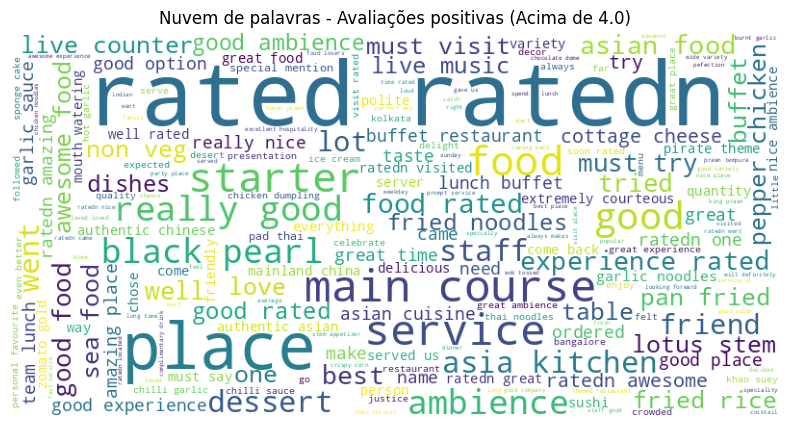

In [63]:
plt.figure(figsize = (10,5))
plt.imshow(wordcloud_positiva)
plt.axis('off')
plt.title('Nuvem de palavras - Avaliações positivas (Acima de 4.0)')
plt.show()

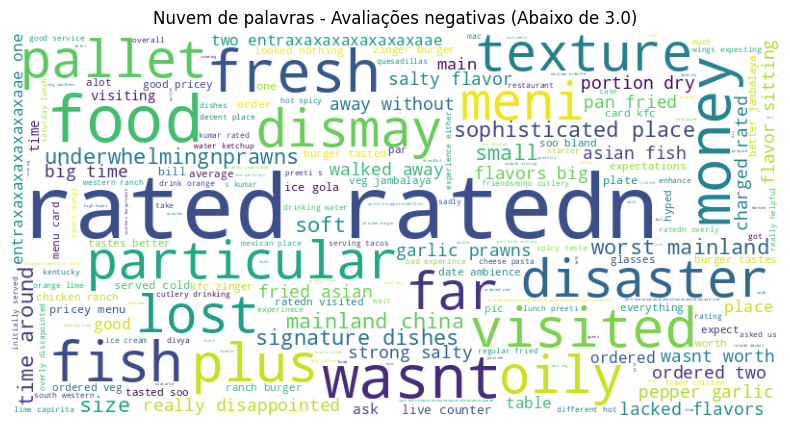

In [64]:
plt.figure(figsize = (10,5))
plt.imshow(wordcloud_negativa)
plt.axis('off')
plt.title('Nuvem de palavras - Avaliações negativas (Abaixo de 3.0)')
plt.show()

### Criando um relatório em HTML

Por fim, podemos consolidar todas as nossas análises em um relatório visual que reúna tanto as informações quantitativas quanto as visualizações que fizemos ao longo do processo. Ao gerar um arquivo HTML, conseguimos criar um documento interativo e visualmente atraente, no qual todas as análises exploratórias, gráficos, e insights obtidos com os dados dos restaurantes serão apresentados de forma clara.

Esse relatório pode ser compartilhado com stakeholders, como gestores e investidores, fornecendo uma visão abrangente sobre o desempenho dos restaurantes e os pontos-chave que impactam o sucesso da franquia.

O processo de geração do relatório nos permite não apenas transmitir os dados brutos, mas também contar uma história convincente com base em evidências, ajudando na tomada de decisão estratégica para a nova franquia.

In [65]:
!jupyter nbconvert --to html --no-input --output=analise_restaurantes.html /content/Análise_com_Polars.ipynb

[NbConvertApp] Converting notebook /content/Análise_com_Polars.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 7998541 bytes to /content/analise_restaurantes.html
